<a href="https://colab.research.google.com/github/Dipto1971/Statistical-Analysis-Data-Science/blob/main/Political%20Crowdsourcing/%20Political_Crowdsourcing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from scipy.stats import shapiro, normaltest
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from statsmodels.formula.api import ols

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/PC-SM.csv')

# Labeling columns with respect to child variables

In [6]:
label_columns = ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'PS7', 'PS8', 'PS9'
                  , 'SMUT1', 'SMUT2', 'SMUT3', 'SMUT4', 'SMUT5', 'SMUT6', 'SMUT7', 'SMUT8', 'SMUT9'
                  , 'OSC1' , 'OSC2' , 'OSC3' , 'OSC4' , 'OSC5' , 'OSC6'
                  , 'VONP1', 'VONP2', 'VONP3', 'VONP4', 'VONP5', 'VONP6', 'VONP7', 'VONP8'
                  , 'VOFP1', 'VOFP2', 'VOFP3', 'VOFP4', 'VOFP5', 'VOFP6', 'VOFP7'
                  , 'PLT1', 'PLT2', 'PLT3', 'PLT4', 'PLT5', 'PLT6', 'PLT7'
                  , 'Gender', 'Age', 'MS', 'RL', 'PI', 'Education Level']

label_columns_to_measure = ['Partisanship',
                            'Social Media Utilization',
                            'Online Social Capital',
                            'Voluntary Online Political Participation',
                            'Voluntary Offline Political Participation',
                            'Political Trust']

In [7]:
variable_groups = {
    'Partisanship': ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'PS7', 'PS8', 'PS9'],
    'Social Media Utilization': ['SMUT1', 'SMUT2', 'SMUT3', 'SMUT4', 'SMUT5', 'SMUT6', 'SMUT7', 'SMUT8', 'SMUT9'],
    'Online Social Capital': ['OSC1', 'OSC2', 'OSC3', 'OSC4', 'OSC5', 'OSC6'],
    'Voluntary Online Political Participation': ['VONP1', 'VONP2', 'VONP3', 'VONP4', 'VONP5', 'VONP6', 'VONP7', 'VONP8'],
    'Voluntary Offline Political Participation': ['VOFP1', 'VOFP2', 'VOFP3', 'VOFP4', 'VOFP5', 'VOFP6', 'VOFP7'],
    'Political Trust': ['PLT1', 'PLT2', 'PLT3', 'PLT4', 'PLT5', 'PLT6', 'PLT7']
}

# Checking Info

In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472 entries, 0 to 471
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               472 non-null    int64
 1   PS1              472 non-null    int64
 2   PS2              472 non-null    int64
 3   PS3              472 non-null    int64
 4   PS4              472 non-null    int64
 5   PS5              472 non-null    int64
 6   PS6              472 non-null    int64
 7   PS7              472 non-null    int64
 8   PS8              472 non-null    int64
 9   PS9              472 non-null    int64
 10  SMUT1            472 non-null    int64
 11  SMUT2            472 non-null    int64
 12  SMUT3            472 non-null    int64
 13  SMUT4            472 non-null    int64
 14  SMUT5            472 non-null    int64
 15  SMUT6            472 non-null    int64
 16  SMUT7            472 non-null    int64
 17  SMUT8            472 non-null    int64
 18  SMUT9     

# Boxplot

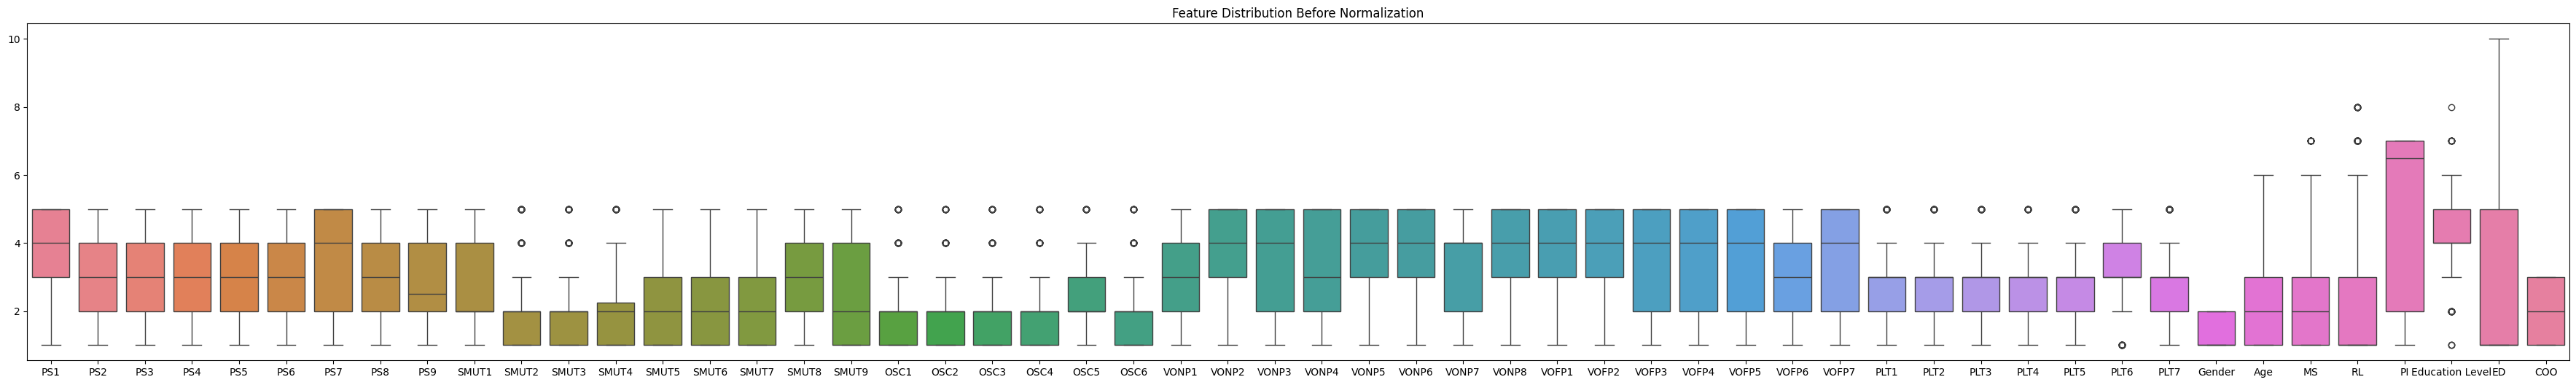

In [9]:
plt.figure(figsize=(45, 6))
sns.boxplot(data=df.iloc[:, 1:])
plt.title("Feature Distribution Before Normalization")
plt.show()

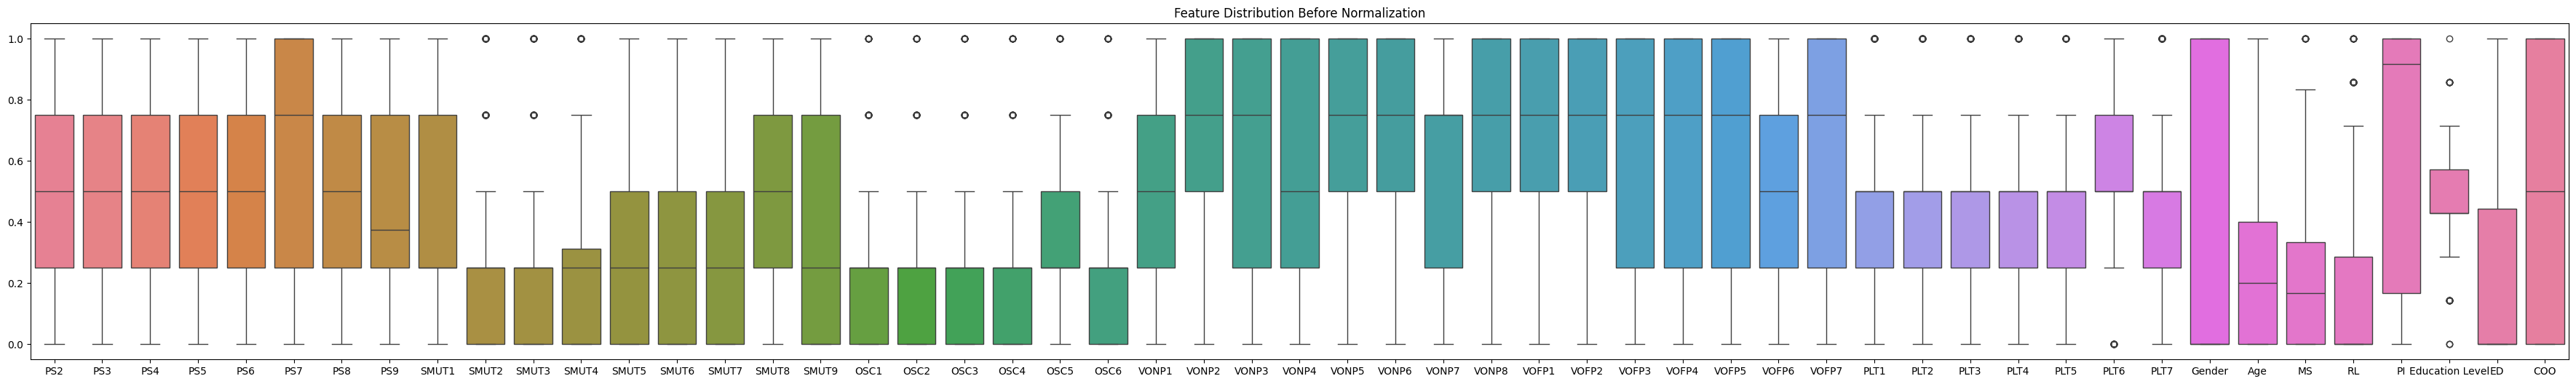

In [10]:
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(df.iloc[:, 1:]), columns=df.columns[1:])
plt.figure(figsize=(45, 6))
sns.boxplot(data=normalized_data.iloc[:, 1:])
plt.title("Feature Distribution Before Normalization")
plt.show()

# Correlation Heatmap Before

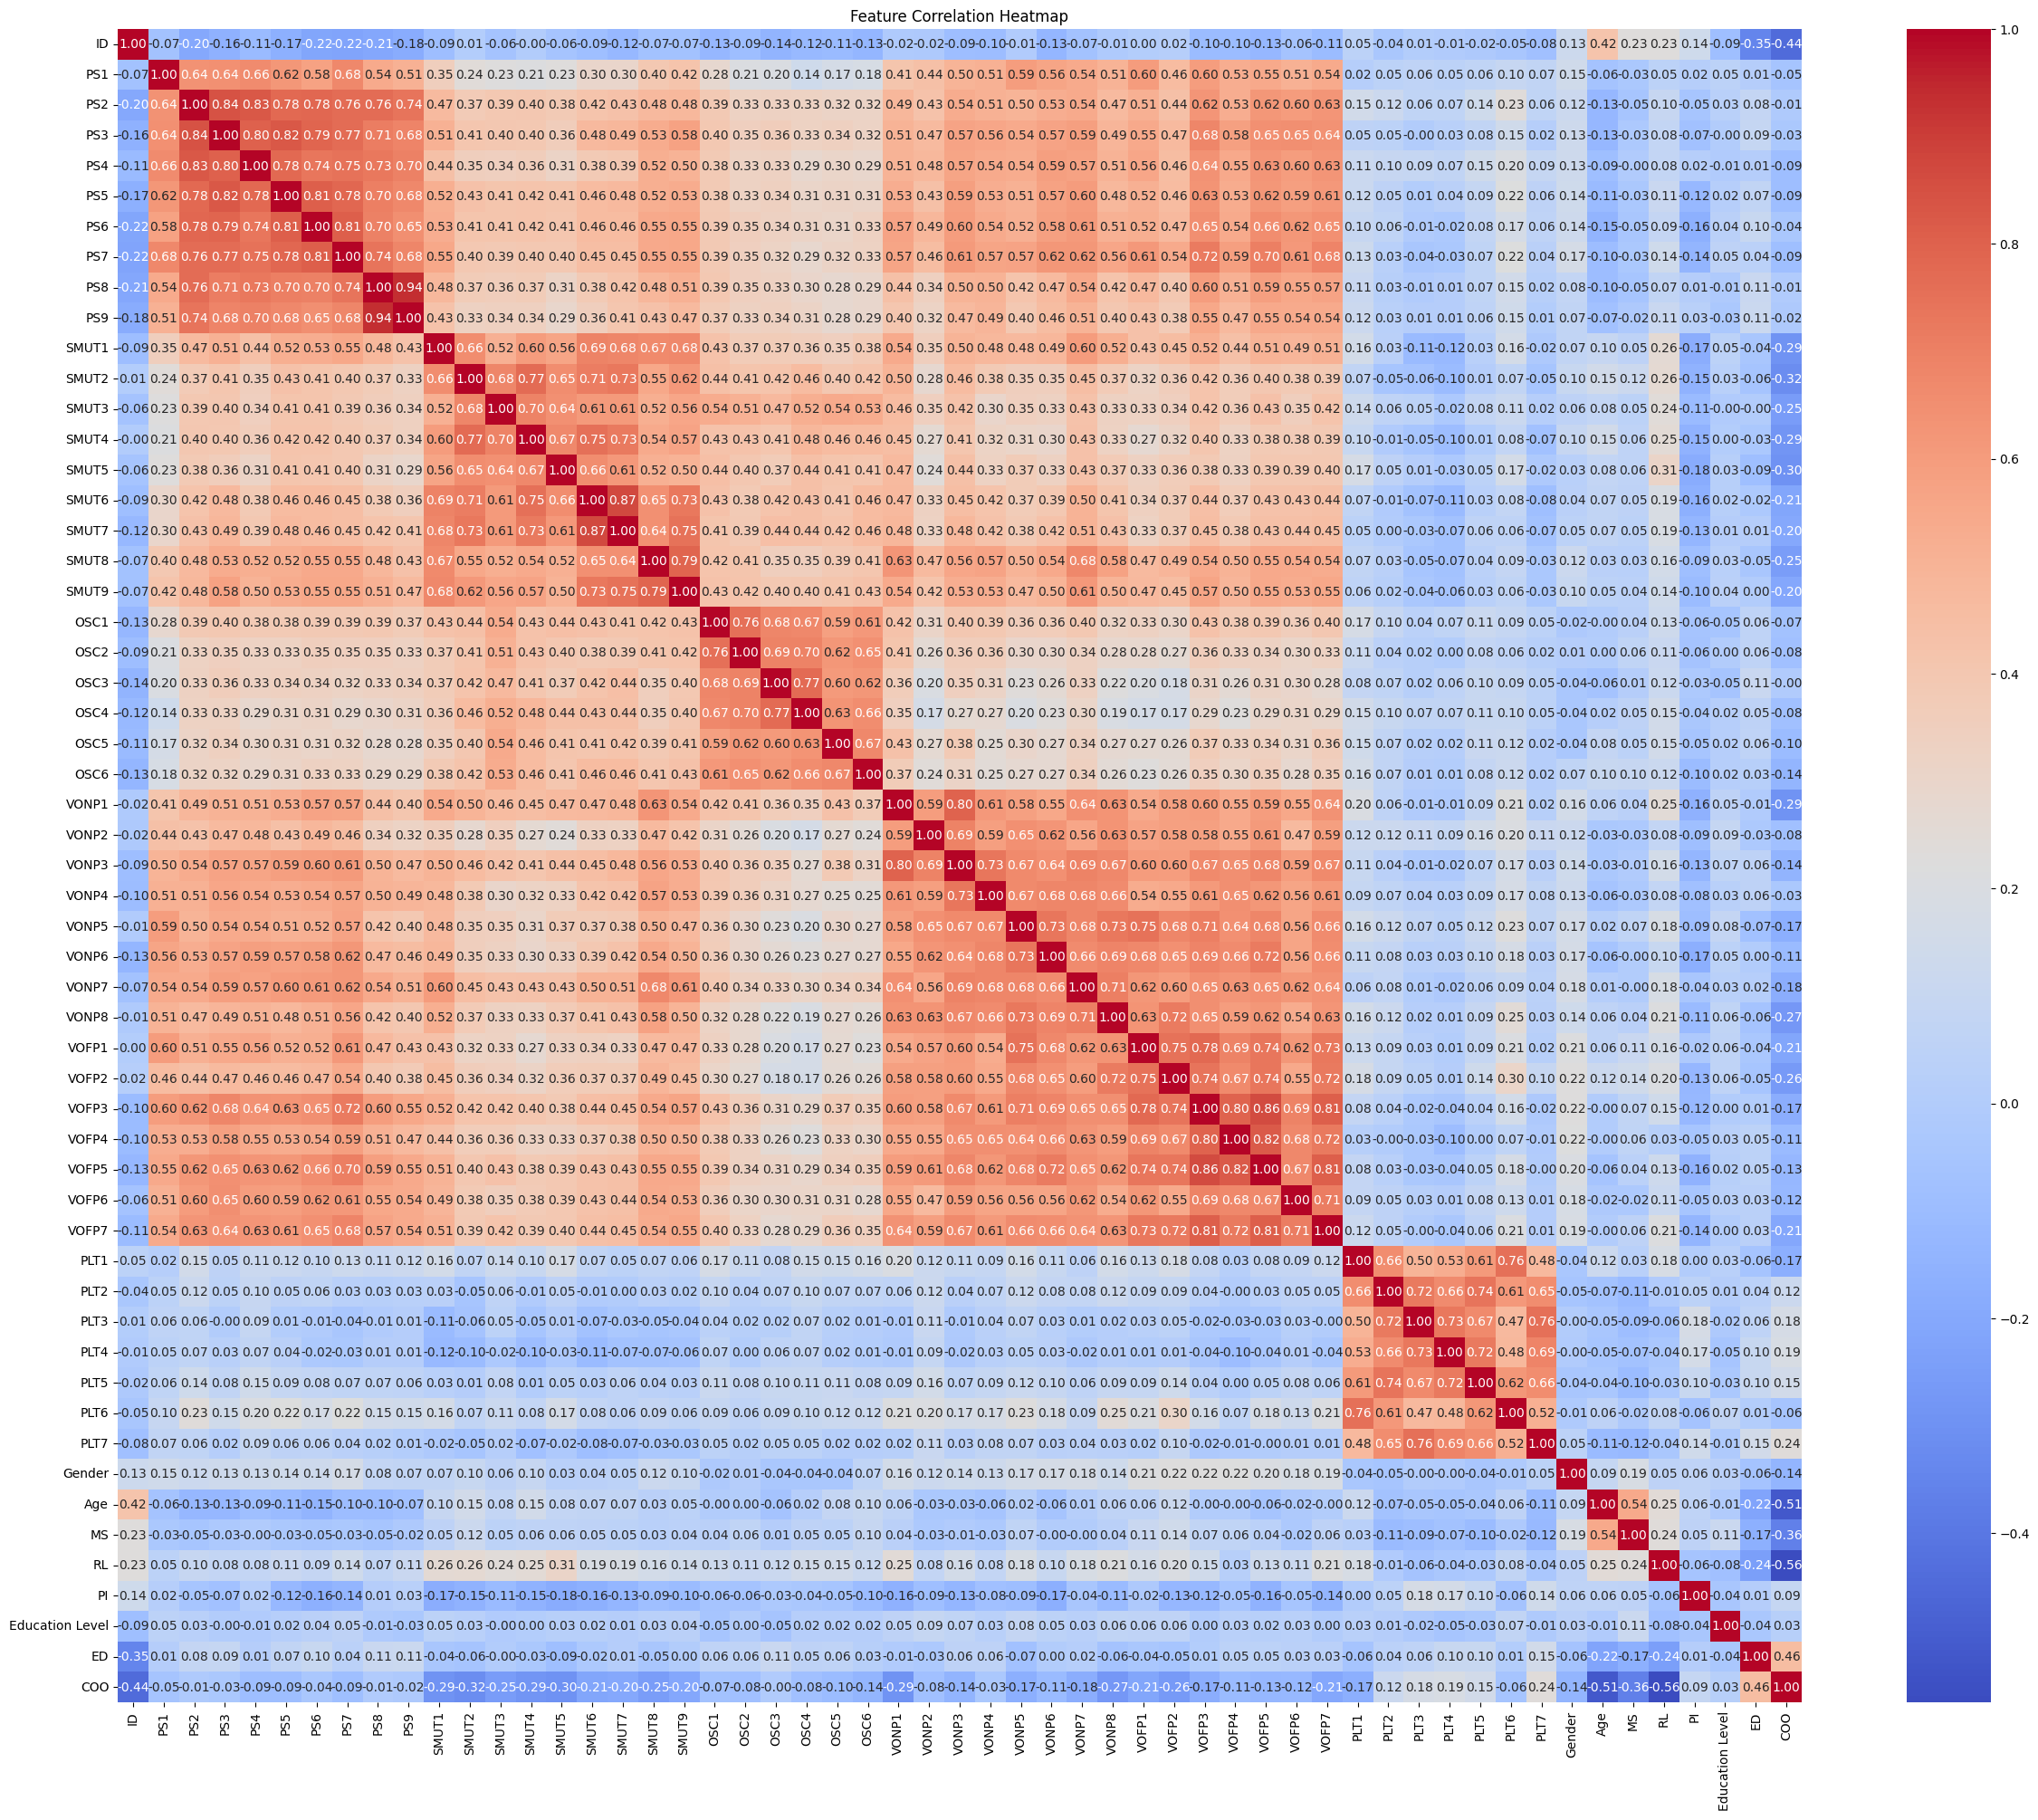

In [11]:
correlation_matrix = df.corr()

plt.figure(figsize=(30, 24))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Checking High correlated features with target variable (PS1-PS9)

In [12]:
import itertools

def find_high_correlations(dataframe, plt_prefix, plt_range, threshold=0.1):
    """
    Find correlations of features starting with a specific prefix (e.g., PLT) with other features.

    Parameters:
        dataframe (pd.DataFrame): The input DataFrame.
        plt_prefix (str): The prefix of the features to consider (e.g., 'PLT').
        plt_range (int): The range of PLT features (e.g., 9 for PLT1 to PLT9).
        threshold (float): The correlation threshold. Defaults to 0.30.

    Returns:
        list of tuples: List containing tuples of feature pairs and their correlation value.
    """
    plt_features = [f"{plt_prefix}{i}" for i in range(1, plt_range + 1)]

    plt_features = [feature for feature in plt_features if feature in dataframe.columns]

    correlation_matrix = dataframe.corr()

    high_corr_pairs = [
        (plt_feature, column, correlation_matrix.loc[plt_feature, column])
        for plt_feature in plt_features
        for column in correlation_matrix.columns
        if (
            plt_feature != column and
            (correlation_matrix.loc[plt_feature, column]) > threshold and
            correlation_matrix.loc[plt_feature, column] != 1
            and column not in plt_features
        )
    ]

    high_corr_pairs.sort(key=lambda x: (x[2]), reverse=True)

    return high_corr_pairs

PLT_correlated = (find_high_correlations(df, 'PS', 9))
display(PLT_correlated)

[('PS7', 'VOFP3', 0.7158051977550789),
 ('PS7', 'VOFP5', 0.7036718441879598),
 ('PS7', 'VOFP7', 0.6840997055652945),
 ('PS3', 'VOFP3', 0.6829516092845354),
 ('PS6', 'VOFP5', 0.6560520413873592),
 ('PS6', 'VOFP3', 0.6526318985311238),
 ('PS3', 'VOFP6', 0.6506044825241499),
 ('PS3', 'VOFP5', 0.6464454689726354),
 ('PS6', 'VOFP7', 0.6452146450573235),
 ('PS4', 'VOFP3', 0.640148235961314),
 ('PS3', 'VOFP7', 0.6380917802050863),
 ('PS5', 'VOFP3', 0.6337064709179754),
 ('PS2', 'VOFP7', 0.626115718156579),
 ('PS4', 'VOFP5', 0.625354331849193),
 ('PS4', 'VOFP7', 0.625274220210035),
 ('PS2', 'VOFP3', 0.6249153180248388),
 ('PS7', 'VONP7', 0.6215802393944561),
 ('PS2', 'VOFP5', 0.6214113342816328),
 ('PS5', 'VOFP5', 0.6207172523063106),
 ('PS7', 'VONP6', 0.6200741826474375),
 ('PS6', 'VOFP6', 0.6189674179758925),
 ('PS7', 'VOFP1', 0.6141596887315588),
 ('PS7', 'VOFP6', 0.6134547904124575),
 ('PS5', 'VOFP7', 0.6110283076722006),
 ('PS7', 'VONP3', 0.6092239056313559),
 ('PS6', 'VONP7', 0.608414358

In [13]:
def plot_encoded_features(dataframe, feature_prefix, feature_range):
    """
    Plot countplots for label-encoded features with a specific prefix and range, all in one display.

    Parameters:
        dataframe (pd.DataFrame): The input DataFrame.
        feature_prefix (str): The prefix of the features to consider (e.g., 'VONP').
        feature_range (int): The number of features to consider (e.g., 8 for VONP1 to VONP8).
    """
    features = [f"{feature_prefix}{i}" for i in range(1, feature_range + 1)]

    features = [feature for feature in features if feature in dataframe.columns]

    num_features = len(features)
    cols = 3
    rows = -(-num_features // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        sns.countplot(data=dataframe, x=feature, palette="coolwarm", ax=axes[idx])
        axes[idx].set_title(f"Countplot of {feature}")
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel("Count")

    for idx in range(num_features, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

# Keeping the features with high correlation

In [14]:
features_to_keep = set()
for feature1, feature2, _ in PLT_correlated:
    features_to_keep.add(feature1)
    features_to_keep.add(feature2)

df_filtered = df[list(features_to_keep)]

print(df_filtered)

     PS8  SMUT7  VOFP3  SMUT4  OSC1  OSC4  OSC5  PS6  VONP3  PLT1  ...  PS1  \
0      4      2      5      2     1     2     2    4      4     3  ...    4   
1      3      1      4      1     1     1     1    3      2     2  ...    4   
2      3      2      5      2     2     2     3    4      4     4  ...    5   
3      3      2      4      2     2     2     3    3      4     2  ...    5   
4      3      2      4      1     2     2     2    3      3     2  ...    4   
..   ...    ...    ...    ...   ...   ...   ...  ...    ...   ...  ...  ...   
467    5      2      4      2     2     2     2    5      4     3  ...    5   
468    3      2      5      2     2     2     2    5      5     2  ...    5   
469    3      2      5      2     2     2     2    5      5     2  ...    5   
470    1      4      5      4     4     4     2    4      5     2  ...    5   
471    2      4      4      4     2     2     2    4      4     3  ...    5   

     PLT5  PS7  RL  PLT6  VOFP7  VOFP1  VOFP5  Gend

# Dropping Features

In [15]:
features_to_drop = ['ED', 'RL', 'Gender']
df_filtered = df_filtered.drop(features_to_drop, axis=1)

# Correlation Matrix After

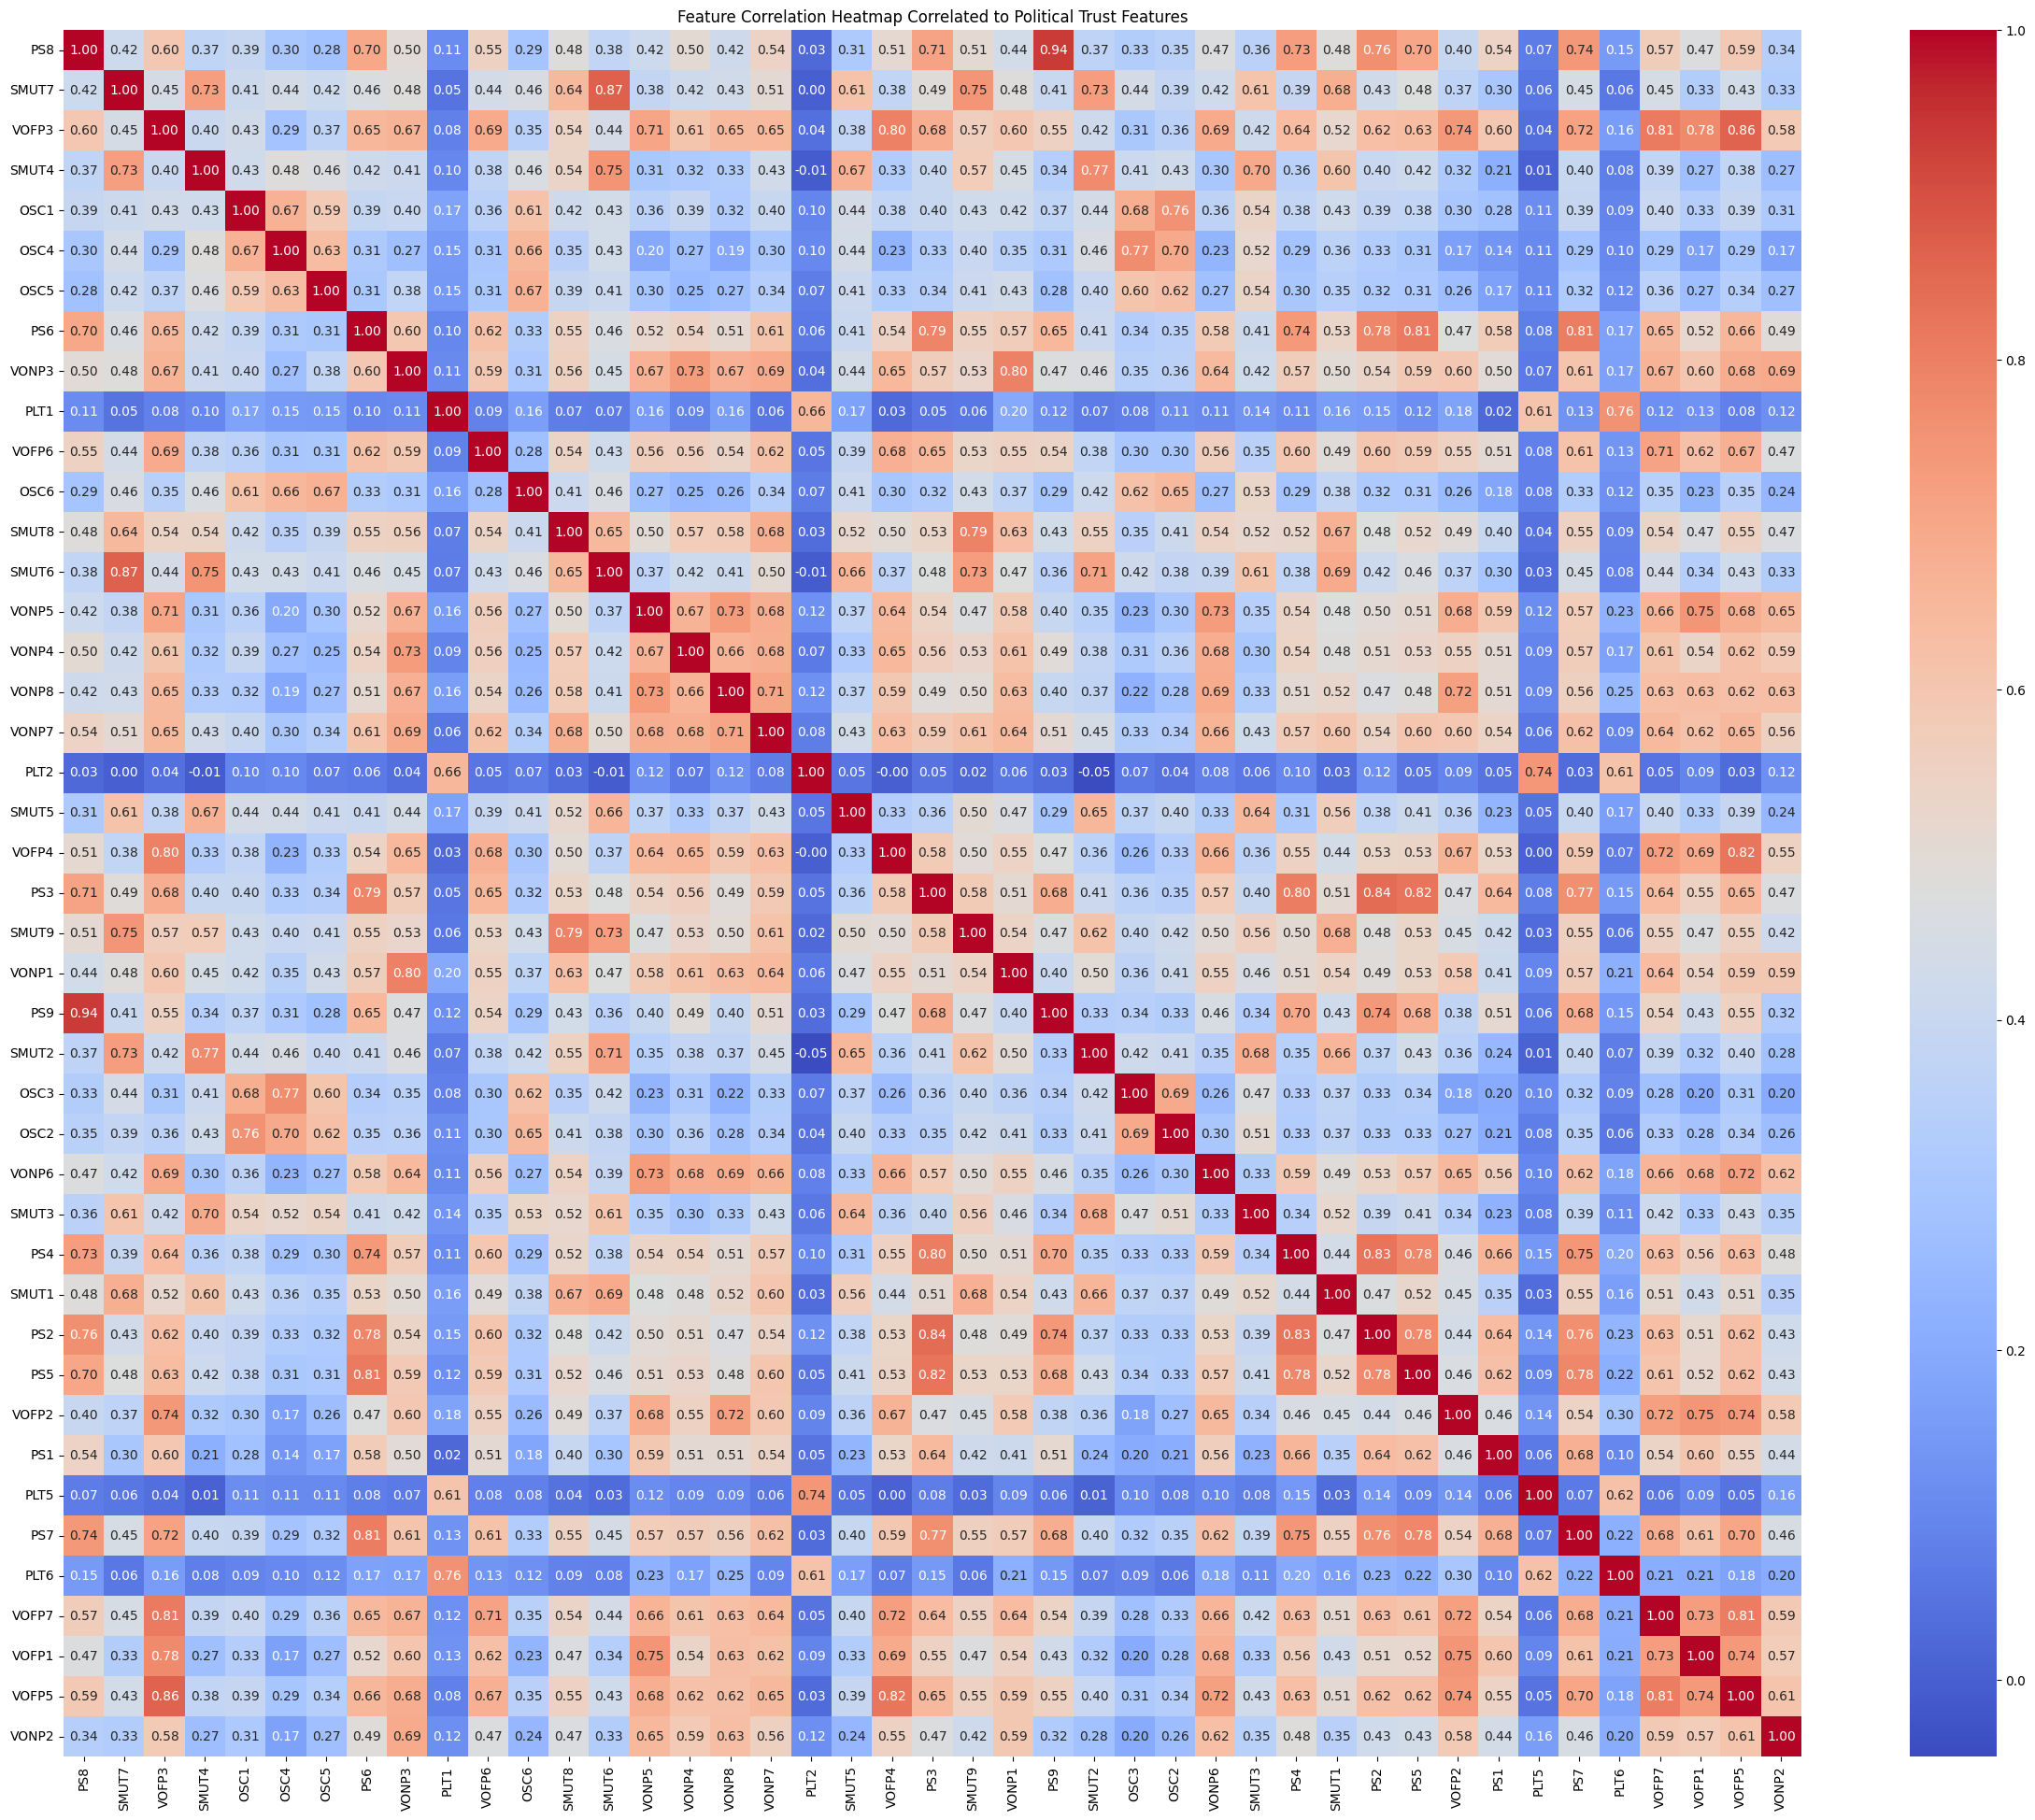

In [16]:
correlation_matrix = df_filtered.corr()

plt.figure(figsize=(30, 24))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap Correlated to Political Trust Features')
plt.show()

# Hypothesis Testing (Chi-Square Test)

In [17]:
#Chi-square test function

import numpy as np
import scipy.stats as stats

def chi_square_test(observed, alpha=0.05):
    chi2, p_value, dof, expected = stats.chi2_contingency(observed)
    critical_value = stats.chi2.ppf(1 - alpha, dof)
    reject_null = chi2 > critical_value

    return chi2, p_value, dof, expected, reject_null, critical_value

In [18]:
import numpy as np
from collections import defaultdict
from scipy.stats import chi2_contingency, chi2

def analyze_features(data, feature1, feature2, alpha=0.05):
    print(f"Analyzing features: {feature1} and {feature2}")
    """
    Analyzes the relationship between two features using the Chi-Square Test.

    Parameters:
        data (DataFrame): The dataset containing the features.
        feature1 (str): The name of the first feature.
        feature2 (str): The name of the second feature.
        alpha (float): The significance level for the Chi-Square Test.

    Returns:
        dict: Results containing the Chi-Square statistic, p-value, degrees of freedom,
              expected frequencies, and whether the null hypothesis is rejected.
    """
    counts = defaultdict(list)

    feature1_values = sorted(data[feature1].unique())
    feature2_values = sorted(data[feature2].unique())

    print(f"Unique values of {feature1}: {feature1_values}")
    print(f"Unique values of {feature2}: {feature2_values}")

    for val1 in feature1_values:
        for val2 in feature2_values:
            filtered_data = data[(data[feature1] == val1) & (data[feature2] == val2)]
            counts[val2].append(len(filtered_data))

    arrays = [counts[val2] for val2 in feature2_values]

    print(f"Counts for {feature2}: {arrays}")

    observed = np.array(arrays)

    chi2_stat, p_value, dof, expected, reject_null, critical_value= chi_square_test(observed)
    critical_value = chi2.ppf(1 - alpha, dof)
    reject_null = p_value < alpha

    print("Chi-Square Statistic:", chi2_stat)
    print("P-value:", p_value)
    print("Degrees of Freedom:", dof)
    print("Expected Frequencies:\n", expected)
    print("Critical Value (alpha=0.05):", critical_value)
    print("H0 " + ("Rejected" if reject_null else "Accepted"))

    return {
        "chi2_stat": chi2_stat,
        "p_value": p_value,
        "dof": dof,
        "expected": expected,
        "critical_value": critical_value,
        "reject_null": reject_null
    }


# Hypothesis 1
- H0: There is no association between PLT6 and VOFP2
- H1: There is association between PLT6 and VOFP2

In [19]:
chi_result = analyze_features(df_filtered, 'PLT6', 'VOFP2')

Analyzing features: PLT6 and VOFP2
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of VOFP2: [1, 2, 3, 4, 5]
Counts for VOFP2: [[7, 4, 3, 2, 1], [3, 5, 8, 2, 2], [7, 17, 98, 10, 2], [4, 28, 45, 28, 19], [8, 26, 58, 43, 42]]
Chi-Square Statistic: 122.04537069693762
P-value: 2.2187514129831805e-18
Degrees of Freedom: 16
Expected Frequencies:
 [[ 1.04449153  2.88135593  7.63559322  3.06144068  2.37711864]
 [ 1.22881356  3.38983051  8.98305085  3.60169492  2.79661017]
 [ 8.23305085 22.71186441 60.18644068 24.13135593 18.73728814]
 [ 7.61864407 21.01694915 55.69491525 22.33050847 17.33898305]
 [10.875      30.         79.5        31.875      24.75      ]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (122.045) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and VOFP2.

# Hypothesis 2
- H0: There is no association between PLT6 and VONP8
- H1: There is association between PLT6 and VONP8

In [20]:
chi_result = analyze_features(df_filtered, 'PLT6', 'VONP8')

Analyzing features: PLT6 and VONP8
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of VONP8: [1, 2, 3, 4, 5]
Counts for VONP8: [[7, 3, 7, 3, 2], [4, 7, 15, 4, 3], [4, 18, 96, 6, 3], [4, 25, 47, 36, 18], [10, 27, 47, 36, 40]]
Chi-Square Statistic: 118.08694430169103
P-value: 1.2801146694629625e-17
Degrees of Freedom: 16
Expected Frequencies:
 [[ 1.35169492  3.72881356  9.88135593  3.96186441  3.07627119]
 [ 2.02754237  5.59322034 14.8220339   5.94279661  4.61440678]
 [ 7.8029661  21.52542373 57.04237288 22.87076271 17.75847458]
 [ 7.98728814 22.03389831 58.38983051 23.41101695 18.1779661 ]
 [ 9.83050847 27.11864407 71.86440678 28.81355932 22.37288136]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (118.087) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and VONP8.

# Hypothesis 3
- H0: There is no association between PS7 and VOFP4
- H1: There is association between PS7 and VOFP4

In [21]:
chi_result = analyze_features(df_filtered, 'PS7', 'VOFP4')

Analyzing features: PS7 and VOFP4
Unique values of PS7: [1, 2, 3, 4, 5]
Unique values of VOFP4: [1, 2, 3, 4, 5]
Counts for VOFP4: [[53, 11, 5, 7, 5], [14, 13, 12, 17, 15], [15, 18, 29, 12, 7], [3, 9, 19, 52, 14], [2, 5, 21, 34, 80]]
Chi-Square Statistic: 292.9474417451205
P-value: 7.349742435576867e-53
Degrees of Freedom: 16
Expected Frequencies:
 [[14.93008475  9.61016949 14.75847458 20.93644068 20.76483051]
 [13.08686441  8.42372881 12.93644068 18.35169492 18.20127119]
 [14.93008475  9.61016949 14.75847458 20.93644068 20.76483051]
 [17.87923729 11.50847458 17.67372881 25.0720339  24.86652542]
 [26.17372881 16.84745763 25.87288136 36.70338983 36.40254237]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 8 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.29). Total Calculated Chi-Square (292.94) > Critical Chi-Square Value (26.29) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PS7 and VOFP4.

# Hypothesis 4
- H0: There is no association between PLT6 and PS2
- H1: There is association between PLT6 and PS2

In [22]:
chi_result = analyze_features(df_filtered, 'PLT6', 'PS2')

Analyzing features: PLT6 and PS2
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of PS2: [1, 2, 3, 4, 5]
Counts for PS2: [[10, 11, 63, 6, 8], [11, 25, 48, 20, 10], [4, 19, 47, 13, 11], [1, 16, 19, 29, 17], [3, 9, 35, 17, 20]]
Chi-Square Statistic: 69.72474028607829
P-value: 1.1150074103832124e-08
Degrees of Freedom: 16
Expected Frequencies:
 [[ 6.02118644 16.61016949 44.01694915 17.64830508 13.70338983]
 [ 7.00423729 19.3220339  51.20338983 20.52966102 15.94067797]
 [ 5.77542373 15.93220339 42.22033898 16.9279661  13.1440678 ]
 [ 5.03813559 13.89830508 36.83050847 14.76694915 11.46610169]
 [ 5.16101695 14.23728814 37.72881356 15.12711864 11.74576271]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (69.72) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and PS2.

# Hypothesis 5
- H0: There is no association between PLT6 and VONP5
- H1: There is association between PLT6 and VONP5

In [23]:
chi_result = analyze_features(df_filtered, 'PLT6', 'VONP5')

Analyzing features: PLT6 and VONP5
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of VONP5: [1, 2, 3, 4, 5]
Counts for VONP5: [[6, 6, 16, 2, 4], [5, 11, 19, 6, 3], [5, 19, 87, 10, 5], [3, 23, 48, 37, 21], [10, 21, 42, 30, 33]]
Chi-Square Statistic: 80.79937224360098
P-value: 1.1938488339072136e-10
Degrees of Freedom: 16
Expected Frequencies:
 [[ 2.08898305  5.76271186 15.27118644  6.12288136  4.75423729]
 [ 2.70338983  7.45762712 19.76271186  7.92372881  6.15254237]
 [ 7.74152542 21.3559322  56.59322034 22.69067797 17.61864407]
 [ 8.11016949 22.37288136 59.28813559 23.77118644 18.45762712]
 [ 8.3559322  23.05084746 61.08474576 24.49152542 19.01694915]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (80.7994) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and VONP5.

# Hypothesis 6
- H0: There is no association between PLT6 and PS7
- H1: There is association between PLT6 and PS7

In [24]:
chi_result = analyze_features(df_filtered, 'PLT6', 'PS7')

Analyzing features: PLT6 and PS7
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of PS7: [1, 2, 3, 4, 5]
Counts for PS7: [[5, 10, 63, 3, 6], [7, 13, 25, 7, 4], [9, 14, 44, 12, 7], [4, 24, 39, 32, 23], [4, 19, 41, 31, 26]]
Chi-Square Statistic: 70.73574870163999
P-value: 7.4142750324629325e-09
Degrees of Freedom: 16
Expected Frequencies:
 [[ 5.34533898 14.74576271 39.07627119 15.66737288 12.16525424]
 [ 3.44067797  9.49152542 25.15254237 10.08474576  7.83050847]
 [ 5.28389831 14.57627119 38.62711864 15.48728814 12.02542373]
 [ 7.49576271 20.6779661  54.79661017 21.97033898 17.05932203]
 [ 7.43432203 20.50847458 54.34745763 21.79025424 16.91949153]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (70.7357) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and PS7.

# Hypothesis 7
- H0: There is no association between PLT6 and PS5
- H1: There is association between PLT6 and PS5

In [25]:
chi_result = analyze_features(df_filtered, 'PLT6', 'PS5')

Analyzing features: PLT6 and PS5
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of PS5: [1, 2, 3, 4, 5]
Counts for PS5: [[4, 10, 58, 1, 6], [10, 17, 32, 15, 10], [12, 25, 48, 21, 10], [1, 17, 39, 26, 20], [2, 11, 35, 22, 20]]
Chi-Square Statistic: 65.00752334231473
P-value: 7.344783026543038e-08
Degrees of Freedom: 16
Expected Frequencies:
 [[ 4.85381356 13.38983051 35.48305085 14.22669492 11.04661017]
 [ 5.16101695 14.23728814 37.72881356 15.12711864 11.74576271]
 [ 7.12711864 19.66101695 52.10169492 20.88983051 16.22033898]
 [ 6.32838983 17.45762712 46.26271186 18.54872881 14.40254237]
 [ 5.52966102 15.25423729 40.42372881 16.20762712 12.58474576]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (65.0075) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and PS5.

# Hypothesis 8
- H0: There is no association between PLT6 and VONP1
- H1: There is association between PLT6 and VONP1

In [26]:
chi_result = analyze_features(df_filtered, 'PLT6', 'VONP1')

Analyzing features: PLT6 and VONP1
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of VONP1: [1, 2, 3, 4, 5]
Counts for VONP1: [[10, 4, 18, 3, 4], [9, 24, 74, 15, 12], [3, 14, 52, 19, 11], [3, 21, 43, 25, 15], [4, 17, 25, 23, 24]]
Chi-Square Statistic: 64.62723225669897
P-value: 8.538135677576367e-08
Degrees of Freedom: 16
Expected Frequencies:
 [[ 2.39618644  6.61016949 17.51694915  7.02330508  5.45338983]
 [ 8.23305085 22.71186441 60.18644068 24.13135593 18.73728814]
 [ 6.08262712 16.77966102 44.46610169 17.82838983 13.84322034]
 [ 6.57415254 18.13559322 48.05932203 19.2690678  14.96186441]
 [ 5.71398305 15.76271186 41.77118644 16.74788136 13.00423729]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (64.6272) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and VONP1.

# Hypothesis 9
- H0: There is no association between PLT6 and VOFP7
- H1: There is association between PLT6 and VOFP7

In [27]:
chi_result = analyze_features(df_filtered, 'PLT6', 'VOFP7')

Analyzing features: PLT6 and VOFP7
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of VOFP7: [1, 2, 3, 4, 5]
Counts for VOFP7: [[10, 8, 43, 5, 3], [8, 10, 53, 16, 5], [2, 11, 31, 8, 6], [4, 22, 43, 32, 19], [5, 29, 42, 24, 33]]
Chi-Square Statistic: 65.33505034786975
P-value: 6.450445388555007e-08
Degrees of Freedom: 16
Expected Frequencies:
 [[ 4.23940678 11.69491525 30.99152542 12.42584746  9.64830508]
 [ 5.65254237 15.59322034 41.3220339  16.56779661 12.86440678]
 [ 3.56355932  9.83050847 26.05084746 10.44491525  8.11016949]
 [ 7.37288136 20.33898305 53.89830508 21.61016949 16.77966102]
 [ 8.17161017 22.54237288 59.73728814 23.95127119 18.59745763]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (65.3350) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and VOFP7.

# Hypothesis 10
- H0: There is no association between PLT6 and VOFP1
- H1: There is association between PLT6 and VOFP1

In [28]:
chi_result = analyze_features(df_filtered, 'PLT6', 'VOFP1')

Analyzing features: PLT6 and VOFP1
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of VOFP1: [1, 2, 3, 4, 5]
Counts for VOFP1: [[8, 8, 13, 4, 3], [9, 9, 23, 7, 12], [1, 15, 87, 13, 4], [5, 23, 46, 26, 14], [6, 25, 43, 35, 33]]
Chi-Square Statistic: 93.13035687595156
P-value: 6.605623684108595e-13
Degrees of Freedom: 16
Expected Frequencies:
 [[ 2.21186441  6.10169492 16.16949153  6.48305085  5.03389831]
 [ 3.68644068 10.16949153 26.94915254 10.80508475  8.38983051]
 [ 7.37288136 20.33898305 53.89830508 21.61016949 16.77966102]
 [ 7.00423729 19.3220339  51.20338983 20.52966102 15.94067797]
 [ 8.72457627 24.06779661 63.77966102 25.5720339  19.8559322 ]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (93.130) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and VOFP1.

# Hypothesis 11
- H0: There is no association between PLT6 and VONP2
- H1: There is association between PLT6 and VONP2

In [29]:
chi_result = analyze_features(df_filtered, 'PLT6', 'VONP2')

Analyzing features: PLT6 and VONP2
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of VONP2: [1, 2, 3, 4, 5]
Counts for VONP2: [[6, 3, 6, 3, 2], [3, 9, 17, 9, 6], [6, 20, 103, 12, 3], [8, 27, 40, 35, 21], [6, 21, 46, 26, 34]]
Chi-Square Statistic: 97.01372152642779
P-value: 1.2529760964897923e-13
Degrees of Freedom: 16
Expected Frequencies:
 [[ 1.22881356  3.38983051  8.98305085  3.60169492  2.79661017]
 [ 2.70338983  7.45762712 19.76271186  7.92372881  6.15254237]
 [ 8.84745763 24.40677966 64.6779661  25.93220339 20.13559322]
 [ 8.04872881 22.20338983 58.83898305 23.59110169 18.31779661]
 [ 8.17161017 22.54237288 59.73728814 23.95127119 18.59745763]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (97.013) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and VONP2.

# Hypothesis 12
- H0: There is no association between PLT6 and PS4
- H1: There is association between PLT6 and PS4

In [30]:
chi_result = analyze_features(df_filtered, 'PLT6', 'PS4')

Analyzing features: PLT6 and PS4
Unique values of PLT6: [1, 2, 3, 4, 5]
Unique values of PS4: [1, 2, 3, 4, 5]
Counts for PS4: [[7, 5, 21, 3, 6], [5, 23, 52, 14, 7], [9, 14, 62, 13, 9], [4, 25, 44, 35, 22], [4, 13, 33, 20, 22]]
Chi-Square Statistic: 51.54268054588832
P-value: 1.2980053253358228e-05
Degrees of Freedom: 16
Expected Frequencies:
 [[ 2.58050847  7.11864407 18.86440678  7.56355932  5.87288136]
 [ 6.20550847 17.11864407 45.36440678 18.18855932 14.12288136]
 [ 6.57415254 18.13559322 48.05932203 19.2690678  14.96186441]
 [ 7.98728814 22.03389831 58.38983051 23.41101695 18.1779661 ]
 [ 5.65254237 15.59322034 41.3220339  16.56779661 12.86440678]]
Critical Value (alpha=0.05): 26.29622760486423
H0 Rejected


With df = 16 and a significance level of 0.05, we can compare this total calculated chi-square value to the critical chi-square value (approximately 26.2962). Total Calculated Chi-Square (51.5427) > Critical Chi-Square Value (26.2962) Since the total calculated chi-square value is greater than the critical chi-square value, we would reject the null hypothesis. This indicates that there is a significant association between PLT6 and PS4.

# Model Fitting

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [32]:
def evaluate_model(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"Model: {model_name}")
    print(confusion_matrix(y_test, y_pred))
    print(f"{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

def modelClassification(X, y, X_train, X_test, y_train, y_test):

    rf_model = RandomForestClassifier(n_estimators= 50, max_depth=None, min_samples_leaf=2, min_samples_split=2, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    # {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}

    svm_model = SVC(kernel='rbf')
    svm_model.fit(X_train, y_train)
    y_pred_svm = svm_model.predict(X_test)

    nn_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=300)
    nn_model.fit(X_train, y_train)
    y_pred_nn = nn_model.predict(X_test)

    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)

    evaluate_model(y_test, y_pred_rf, 'Random Forest')
    evaluate_model(y_test, y_pred_svm, 'SVM')
    evaluate_model(y_test, y_pred_nn, 'Neural Network')
    evaluate_model(y_test, y_pred_xgb, 'XGBoost')
    evaluate_model(y_test, y_pred_lr, 'Logistic Regression')


    return xgb_model, rf_model, svm_model, nn_model, lr_model, y_pred_xgb, y_pred_rf, y_pred_svm, y_pred_nn, y_pred_lr

In [33]:
y = df_filtered['PS7']
X = df_filtered.drop(['PS7'], axis=1)

y_mapped = y - y.min()

X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.3, random_state=42)
xgb_model, rf_model, svm_model, nn_model, lr_model, y_pred_xgb, y_pred_rf, y_pred_svm, y_pred_nn, y_pred_lr = modelClassification(X, y, X_train, X_test, y_train, y_test)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:24:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: Random Forest
[[20  4  0  0  0]
 [ 1  8  1  2  1]
 [ 0  3 11  7  1]
 [ 0  1  4 37  4]
 [ 0  0  0  5 32]]
Random Forest Performance:
Accuracy: 0.7606
Precision: 0.7415
Recall: 0.7236
F1-Score: 0.7272

Model: SVM
[[18  4  1  1  0]
 [ 2  5  4  2  0]
 [ 0  3 14  4  1]
 [ 0  1  3 36  6]
 [ 0  0  0  9 28]]
SVM Performance:
Accuracy: 0.7113
Precision: 0.6827
Recall: 0.6621
F1-Score: 0.6703

Model: Neural Network
[[19  4  1  0  0]
 [ 3  4  2  3  1]
 [ 0  6  9  6  1]
 [ 3  1 13 17 12]
 [ 0  1  8  6 22]]
Neural Network Performance:
Accuracy: 0.5000
Precision: 0.4850
Recall: 0.4945
F1-Score: 0.4835

Model: XGBoost
[[21  2  0  1  0]
 [ 1  6  2  3  1]
 [ 0  5 13  3  1]
 [ 0  1  4 34  7]
 [ 0  0  0  6 31]]
XGBoost Performance:
Accuracy: 0.7394
Precision: 0.7131
Recall: 0.7009
F1-Score: 0.7056

Model: Logistic Regression
[[20  2  2  0  0]
 [ 4  5  2  1  1]
 [ 0  2 10  8  2]
 [ 3  3  8 15 17]
 [ 1  2  5  8 21]]
Logistic Regression Performance:
Accuracy: 0.5000
Precision: 0.4845
Recall: 0.5132
F

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Model Results Comparison

In [34]:
import pandas as pd

model_results = {
    "Model": ["Logistic Regression", "Random Forest", "SVM", "XGBoost", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_nn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average='macro', zero_division=0),
        precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
        precision_score(y_test, y_pred_svm, average='macro', zero_division=0),
        precision_score(y_test, y_pred_xgb, average='macro', zero_division=0),
        precision_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average='macro', zero_division=0),
        recall_score(y_test, y_pred_rf, average='macro', zero_division=0),
        recall_score(y_test, y_pred_svm, average='macro', zero_division=0),
        recall_score(y_test, y_pred_xgb, average='macro', zero_division=0),
        recall_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
        f1_score(y_test, y_pred_rf, average='macro', zero_division=0),
        f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
        f1_score(y_test, y_pred_xgb, average='macro', zero_division=0),
        f1_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ]
}

comparison_df = pd.DataFrame(model_results)

from IPython.display import display
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.500000,0.484549,0.513230,0.494168
1,Random Forest,0.760563,0.741495,0.723586,0.727156
2,SVM,0.711268,0.682657,0.662069,0.670326
3,XGBoost,0.739437,0.713146,0.700883,0.705602
4,Neural Network,0.500000,0.485018,0.494522,0.483456


# Hyper-Parameter Tuning


In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Model Selection: Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

y_pred = best_rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.93        24
           1       0.62      0.77      0.69        13
           2       0.63      0.55      0.59        22
           3       0.70      0.80      0.75        46
           4       0.79      0.70      0.74        37

    accuracy                           0.75       142
   macro avg       0.75      0.74      0.74       142
weighted avg       0.76      0.75      0.75       142



# Learning Curve

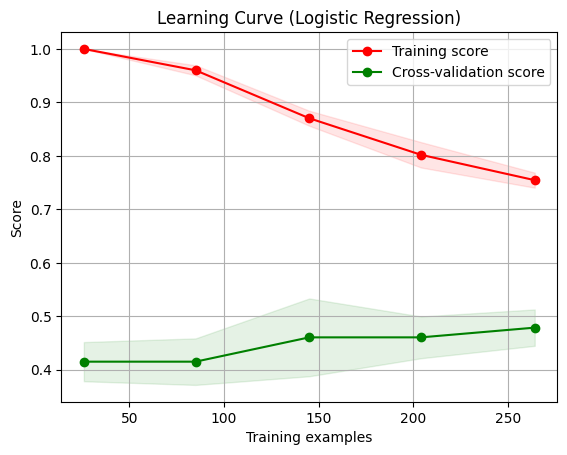

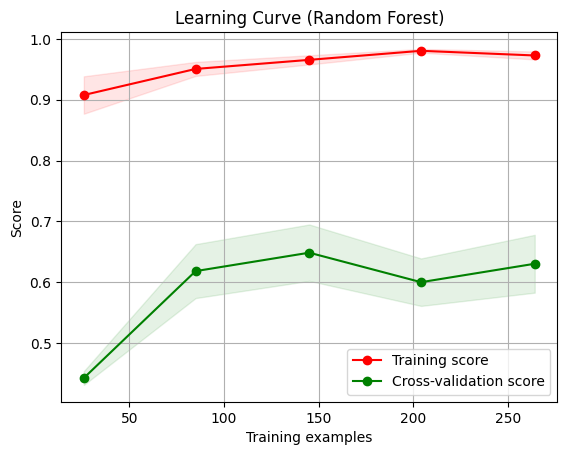

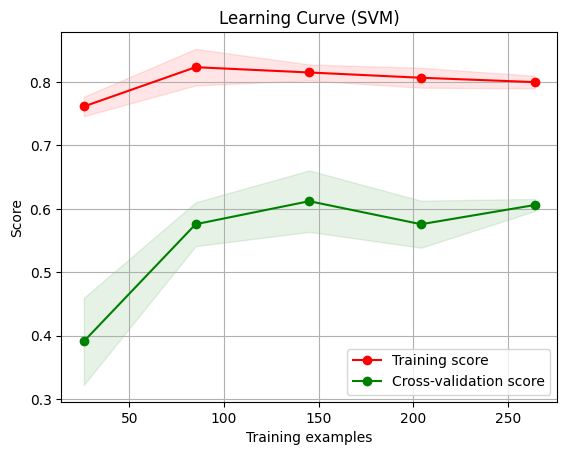

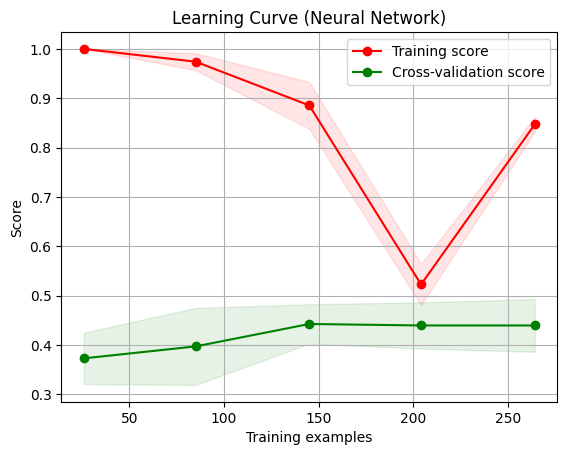

In [36]:
!pip install --upgrade scikit-learn xgboost

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

plot_learning_curve(lr_model, "Learning Curve (Logistic Regression)", X_train, y_train)
plot_learning_curve(rf_model, "Learning Curve (Random Forest)", X_train, y_train)
plot_learning_curve(svm_model, "Learning Curve (SVM)", X_train, y_train)
plot_learning_curve(nn_model, "Learning Curve (Neural Network)", X_train, y_train)

plt.show()

# SHAP

In [37]:
import shap
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators= 50, max_depth=None, min_samples_leaf=2, min_samples_split=2, random_state=42)
rf_model.fit(X_train, y_train)

explainer_rf = shap.TreeExplainer(rf_model, X_train[:10])
shap_values_rf = explainer_rf.shap_values(X_train)

shap.initjs()
shap.force_plot(explainer_rf.expected_value[0], shap_values_rf[0,:,0], X_train.iloc[0,:])

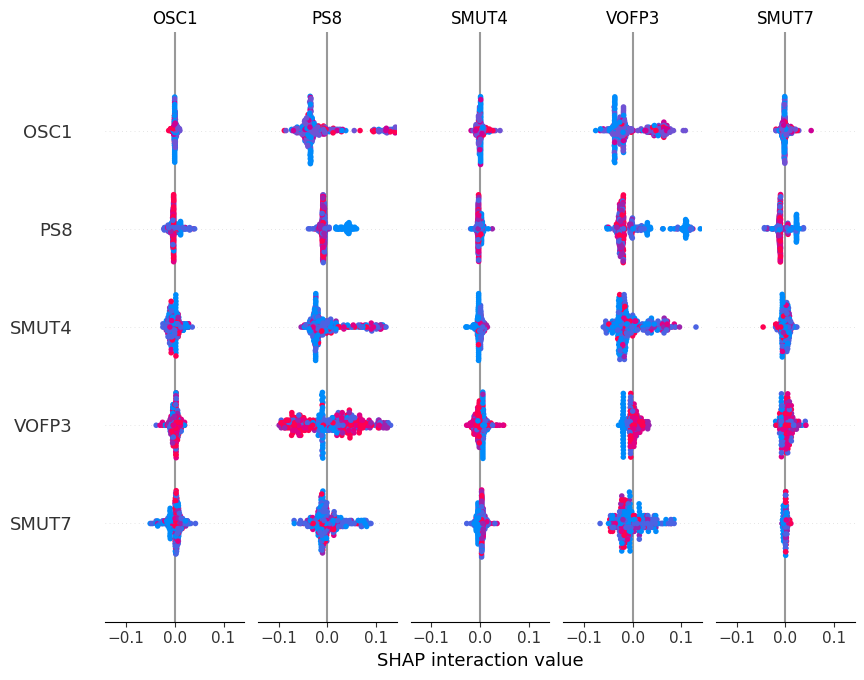

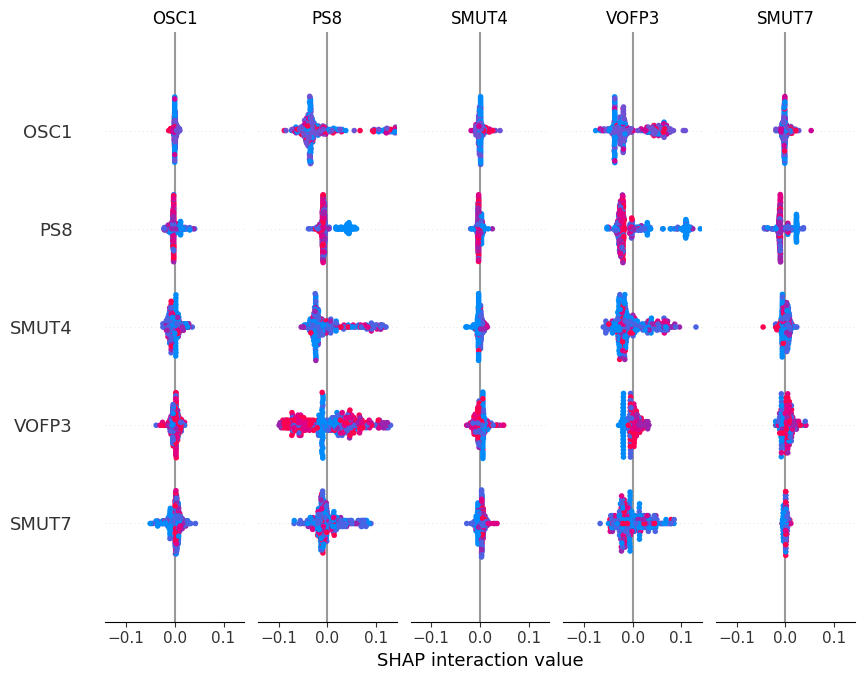

In [38]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type='bar')

shap.summary_plot(shap_values, X_train, plot_type='dot')

# LIME

In [39]:
!pip install lime
import lime
import lime.lime_tabular as lime_tabular

explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],
    mode='classification'
)

i = 1
instance = X_train.iloc[i]

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=rf_model.predict_proba
)

exp.show_in_notebook(show_table=True, show_all=True)

/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

# Making the target feature Balanced

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_test_splitting(df, target_column):
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    y = y - y.min()

    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X, y)

    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

    print(y_res.value_counts())

    return X_res, y_res, X_train, X_test, y_train, y_test

def evaluate_model(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"Model: {model_name}")
    print(confusion_matrix(y_test, y_pred))
    print(f"{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

def modelClassification(X, y, X_train, X_test, y_train, y_test):

    rf_model = RandomForestClassifier(n_estimators=200, max_depth= 10, min_samples_leaf=2, min_samples_split=2, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
#  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

    svm_model = SVC(kernel='rbf')
    svm_model.fit(X_train, y_train)
    y_pred_svm = svm_model.predict(X_test)

    nn_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=300)
    nn_model.fit(X_train, y_train)
    y_pred_nn = nn_model.predict(X_test)

    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)

    evaluate_model(y_test, y_pred_rf, 'Random Forest')
    evaluate_model(y_test, y_pred_svm, 'SVM')
    evaluate_model(y_test, y_pred_nn, 'Neural Network')
    evaluate_model(y_test, y_pred_xgb, 'XGBoost')
    evaluate_model(y_test, y_pred_lr, 'Logistic Regression')


    return xgb_model, rf_model, svm_model, nn_model, lr_model, y_pred_xgb, y_pred_rf, y_pred_svm, y_pred_nn, y_pred_lr

# Counting in each features

In [41]:
import pandas as pd

def count_values_in_dataframe(df):
    """
    Counts the occurrences of values [1, 2, 3, 4, 5] in a DataFrame.

    Args:
        df (pd.DataFrame): Input DataFrame.

    Returns:
        pd.DataFrame: A DataFrame with counts of each value for each column.
    """
    # Define the target values
    target_values = [1, 2, 3, 4, 5]

    # Initialize a dictionary to store results
    result = {}

    # Iterate through each column in the DataFrame
    for col in df.columns:
        # Count the occurrences of each target value in the column
        counts = df[col].value_counts()
        result[col] = {value: counts.get(value, 0) for value in target_values}

    # Convert the results to a DataFrame
    count_df = pd.DataFrame(result).T
    count_df.columns = target_values

    return count_df

In [42]:
count_values = count_values_in_dataframe(df_filtered)
print(count_values)

         1    2    3    4    5
PS8    100  116   90   92   74
SMUT7  141  172   59   52   48
VOFP3   76   92   55  100  149
SMUT4  171  183   49   39   30
OSC1   127  236   69   29   11
OSC4   159  233   44   23   13
OSC5    96  216  110   35   15
PS6     88   72  100  130   82
VONP3   39  105   90  116  122
PLT1    43  126  190   66   47
VOFP6   96  110   83   88   95
OSC6   141  222   60   33   16
SMUT8   87  133   83   83   86
SMUT6  134  165   65   67   41
VONP5   34   44  126  132  136
VONP4   49  116   76  111  120
VONP8   22   33  127  130  160
VONP7   50   99   84  124  115
PLT2    54  147  173   60   38
SMUT5  162  187   46   44   33
VOFP4   81   71   81   97  142
PS3     96   89   95  110   82
SMUT9  120  157   67   67   61
VONP1   39  134   99  107   93
PS9    108  128   85   77   74
SMUT2  159  196   33   43   41
OSC3   132  233   65   27   15
OSC2   124  253   56   26   13
VONP6   47   51   95  125  154
SMUT3  150  212   44   38   28
PS4     42  101  107  130   92
SMUT1  1

# Fitting model after balancing the target feature


In [43]:
y = df_filtered['PS7']
X = df_filtered.drop(['PS7'], axis=1)

X, y, X_train, X_test, y_train, y_test = train_test_splitting(df_filtered, 'PS7')
xgb_model, rf_model, svm_model, nn_model, lr_model, y_pred_xgb, y_pred_rf, y_pred_svm, y_pred_nn, y_pred_lr = modelClassification(X, y, X_train, X_test, y_train, y_test)


PS7
3    122
4    122
2    122
1    122
0    122
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:26:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: Random Forest
[[20  2  3  0  0]
 [ 2 22  1  2  1]
 [ 0  1 26  0  0]
 [ 0  1  1 19  3]
 [ 0  0  0  5 13]]
Random Forest Performance:
Accuracy: 0.8197
Precision: 0.8179
Recall: 0.8125
F1-Score: 0.8131

Model: SVM
[[17  6  1  1  0]
 [ 2 18  4  3  1]
 [ 0  6 17  4  0]
 [ 0  1  3 18  2]
 [ 0  0  0  7 11]]
SVM Performance:
Accuracy: 0.6639
Precision: 0.6973
Recall: 0.6627
F1-Score: 0.6712

Model: Neural Network
[[19  6  0  0  0]
 [ 2 23  0  2  1]
 [ 1  3 17  4  2]
 [ 0  3  7  7  7]
 [ 0  2  1  4 11]]
Neural Network Performance:
Accuracy: 0.6311
Precision: 0.6202
Recall: 0.6228
F1-Score: 0.6151

Model: XGBoost
[[23  0  1  1  0]
 [ 2 20  3  2  1]
 [ 0  2 24  0  1]
 [ 0  1  1 19  3]
 [ 0  0  1  3 14]]
XGBoost Performance:
Accuracy: 0.8197
Precision: 0.8173
Recall: 0.8185
F1-Score: 0.8157

Model: Logistic Regression
[[19  3  3  0  0]
 [ 2 16  6  2  2]
 [ 1  2 16  7  1]
 [ 1  3  8  7  5]
 [ 0  1  3  4 10]]
Logistic Regression Performance:
Accuracy: 0.5574
Precision: 0.5632
Recall: 0.5542
F

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Comparison


In [44]:
import pandas as pd

model_results = {
    "Model": ["Logistic Regression", "Random Forest", "SVM", "XGBoost", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_nn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average='macro', zero_division=0),
        precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
        precision_score(y_test, y_pred_svm, average='macro', zero_division=0),
        precision_score(y_test, y_pred_xgb, average='macro', zero_division=0),
        precision_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average='macro', zero_division=0),
        recall_score(y_test, y_pred_rf, average='macro', zero_division=0),
        recall_score(y_test, y_pred_svm, average='macro', zero_division=0),
        recall_score(y_test, y_pred_xgb, average='macro', zero_division=0),
        recall_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
        f1_score(y_test, y_pred_rf, average='macro', zero_division=0),
        f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
        f1_score(y_test, y_pred_xgb, average='macro', zero_division=0),
        f1_score(y_test, y_pred_nn, average='macro', zero_division=0)
    ]
}

comparison_df = pd.DataFrame(model_results)

from IPython.display import display
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.557377,0.563217,0.554249,0.555423
1,Random Forest,0.819672,0.817886,0.812513,0.813058
2,SVM,0.663934,0.697310,0.662720,0.671164
3,XGBoost,0.819672,0.817281,0.818524,0.815737
4,Neural Network,0.631148,0.620166,0.622767,0.615123


# Tuning


In [45]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

y_pred = best_rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.88        25
           1       0.81      0.75      0.78        28
           2       0.76      0.93      0.83        27
           3       0.60      0.62      0.61        24
           4       0.73      0.61      0.67        18

    accuracy                           0.76       122
   macro avg       0.76      0.75      0.75       122
weighted avg       0.77      0.76      0.76       122



# Shap


In [46]:
import shap
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators= 200, max_depth= 10, min_samples_leaf= 2, min_samples_split= 2, random_state= 42)
# {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
rf_model.fit(X_train, y_train)

explainer_rf = shap.TreeExplainer(rf_model, X_train[:10])
shap_values_rf = explainer_rf.shap_values(X_train)

shap.initjs()
shap.force_plot(explainer_rf.expected_value[0], shap_values_rf[0,:,0], X_train.iloc[0,:])

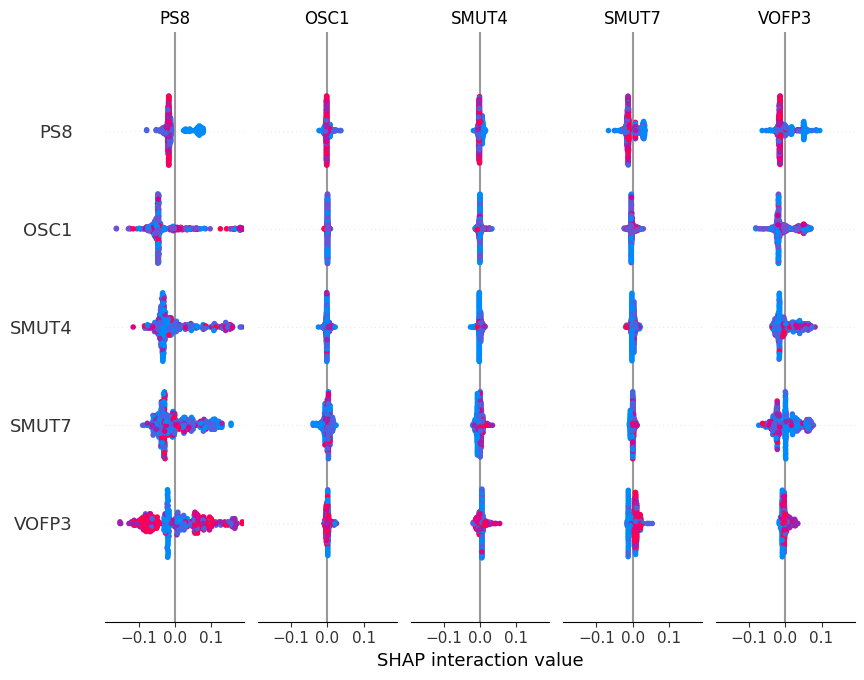

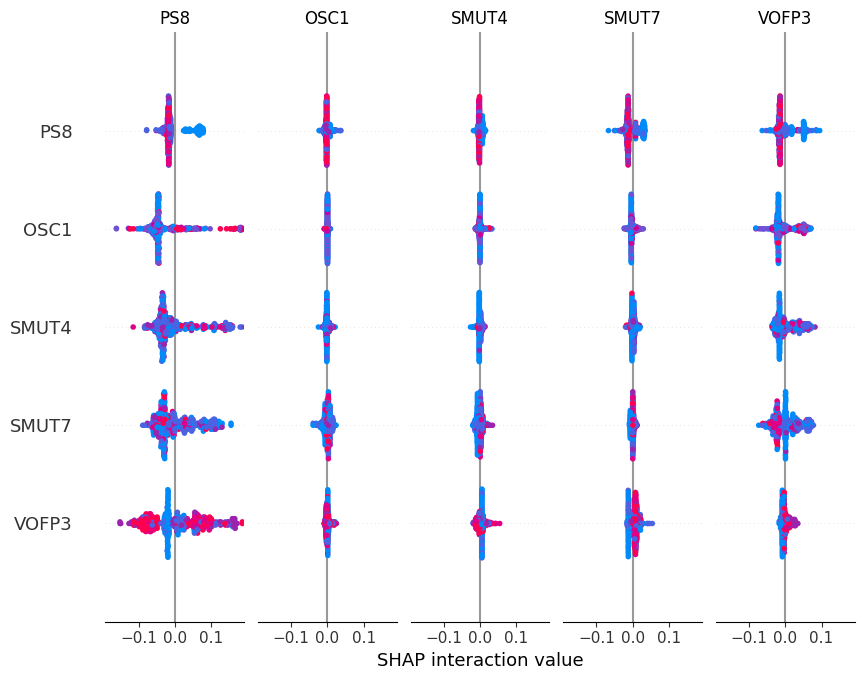

In [48]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar")

shap.summary_plot(shap_values, X_train, plot_type='dot')

# LIME

In [50]:
!pip install lime
import lime
import lime.lime_tabular as lime_tabular

explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],
    mode='classification'
)

i = 1
instance = X_train.iloc[i]

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=rf_model.predict_proba
)

exp.show_in_notebook(show_table=True, show_all=True)

/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.